In [2]:
!pip install kagglehub

In [2]:
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'flickr8k' dataset.
Dataset Path: /kaggle/input/flickr8k


In [3]:
import os
image_folder = "/kaggle/input/flickr8k/Images"

image_paths = [
    os.path.join(image_folder, img)
    for img in os.listdir(image_folder)
    if img.endswith(".jpg")
]

print("Total Images:", len(image_paths))

Total Images: 8091


In [4]:
from transformers import CLIPModel, CLIPProcessor
import torch

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

model.eval()

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, eleme

In [5]:
from PIL import Image

image = Image.open(image_paths[0]).convert("RGB")

inputs = processor(
    images=image,
    return_tensors="pt"
)

with torch.no_grad():
    output = model.get_image_features(**inputs)

print(type(output))
print(output)

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
BaseModelOutputWithPooling(last_hidden_state=tensor([[[ 0.3531,  0.1446, -0.3773,  ...,  0.1227,  0.4363,  0.0624],
         [ 0.2099,  0.5296, -0.3645,  ...,  0.1942,  0.6085,  0.0307],
         [ 0.3820,  0.4536, -0.4556,  ...,  0.8183,  0.5060, -0.2408],
         ...,
         [ 0.2505,  0.4455, -0.3224,  ...,  0.2327,  0.5169, -0.4366],
         [ 0.2576, -0.0637, -0.1037,  ...,  0.0581,  0.8475, -0.1767],
         [ 0.1482,  0.1206, -0.2720,  ...,  0.0896,  0.6744, -0.1534]]]), pooler_output=tensor([[-2.5971e-01,  2.8717e-01,  1.4883e-01,  3.9597e-01, -1.3890e-01,
         -4.2368e-01,  6.0449e-01,  2.3714e-01,  2.3565e-01, -1.3575e-01,
         -2.0764e-01,  3.5050e-02, -1.7243e-01, -5.6920e-01,  4.1926e-01,
         -4.8011e-01, -1.2357e-01,  3.2580e-01, -3.2304e-01,  3.4510e-02,
         -4.7033e-01, -1.1436e-01,  1.0706e-01, -2.6896e-02,  7.7522e-02,
         -2.2117e-01,  3.3037e-01,  3.0659e-01, -1.1386e-01, 

In [9]:
import torch
from PIL import Image

image_embeddings = []

for path in image_paths[:100]:

    image = Image.open(path).convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    with torch.no_grad():
        output = model.get_image_features(**inputs)

    embedding = output.pooler_output

    image_embeddings.append(embedding)

print("Images processed:", len(image_embeddings))
print("Embedding shape:", image_embeddings[0].shape)

Images processed: 100
Embedding shape: torch.Size([1, 512])


In [14]:
query = "a man riding a bicycle"

text_inputs = processor(
    text=[query],
    return_tensors="pt",
    padding=True
)

with torch.no_grad():
    text_output = model.get_text_features(**text_inputs)

text_embedding = text_output.pooler_output

print(text_embedding.shape)

torch.Size([1, 512])


In [15]:
import torch.nn.functional as F

scores = []

for emb in image_embeddings:

    score = F.cosine_similarity(
        text_embedding,
        emb,
        dim=1
    )

    scores.append(score.item())

In [16]:
best_index = scores.index(max(scores))

print("Query:", query)
print("Best image:", image_paths[best_index])
print("Similarity:", scores[best_index])

Query: a man riding a bicycle
Best image: /kaggle/input/flickr8k/Images/2998024845_1529c11694.jpg
Similarity: 0.2728574872016907


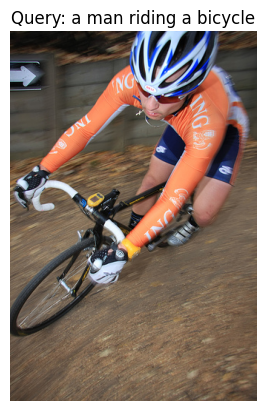

In [17]:
import matplotlib.pyplot as plt

best_image = Image.open(
    image_paths[best_index]
).convert("RGB")

plt.imshow(best_image)
plt.axis("off")
plt.title(f"Query: {query}")
plt.show()